# Assessing the Gender & Skin Tone distribution of the ReLaion-5B & SD images.

In [2]:
import json
from collections import Counter, defaultdict
from pathlib import Path

def extract_profession(image_path: str) -> str:
    """
    Extract profession from 'Profession/filename.png'
    """
    return Path(image_path).parts[0]

def assess_distribution(jsonl_path: str):
    # -------------------------
    # Overall counters
    # -------------------------
    overall_gender = Counter()
    overall_mst = Counter()
    overall_bin = Counter()
    overall_gender_bin = Counter()

    # -------------------------
    # Per-profession counters
    # -------------------------
    per_profession = defaultdict(lambda: {
        "gender": Counter(),
        "mst": Counter(),
        "bin": Counter(),
        "gender_bin": Counter(),
    })

    # -------------------------
    # Read JSONL
    # -------------------------
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)

            image = row["image"]
            gender = row["gender"]
            mst_label = row["mst_label"]
            bin_label = row["bin_label"]
            bin_name = row["bin_name"]

            profession = extract_profession(image)

            # ---- overall
            overall_gender[gender] += 1
            overall_mst[mst_label] += 1
            overall_bin[bin_name] += 1
            overall_gender_bin[(gender, bin_name)] += 1

            # ---- per profession
            p = per_profession[profession]
            p["gender"][gender] += 1
            p["mst"][mst_label] += 1
            p["bin"][bin_name] += 1
            p["gender_bin"][(gender, bin_name)] += 1

    # -------------------------
    # Print results
    # -------------------------
    print("\n=== OVERALL ===")
    print("Gender:", dict(overall_gender))
    print("MST label:", dict(overall_mst))
    print("Bin:", dict(overall_bin))
    print("Gender × Bin:", dict(overall_gender_bin))

    print("\n=== PER PROFESSION ===")
    for profession, stats in sorted(per_profession.items()):
        print(f"\n[{profession}]")
        print("  Gender:", dict(stats["gender"]))
        print("  MST:", dict(stats["mst"]))
        print("  Bin:", dict(stats["bin"]))
        print("  Gender × Bin:", dict(stats["gender_bin"]))

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualise_profession_attribute_distribution(jsonl_path: str, top_k: int = 25, label='mst_label', label_list=None):
    # Load data
    df = pd.read_json(jsonl_path, lines=True)
    df["profession"] = df["image"].str.split("/").str[0]

    # Count samples per profession
    profession_counts = df["profession"].value_counts()

    # Keep top K professions
    top_professions = profession_counts.head(top_k).index

    df_top = df[df["profession"].isin(top_professions)]

    pivot = pd.crosstab(
        df_top["profession"],
        df_top[label],
        normalize="index"
    )
    
    if label_list is not None:
        pivot = pivot.reindex(
            columns=label_list,
            fill_value=0.0
        )

    plt.figure(figsize=(8, 10))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar_kws={"label": "Proportion"}
    )
    plt.title(f"MST Distribution per Profession (Top {top_k})")
    plt.ylabel("Profession")
    plt.xlabel("MST Label (1–10)")
    plt.tight_layout()
    plt.show()

## SD

In [ ]:
jsonl_path = r"StableDiffusionGeneratedImages_Annotations\annotations.jsonl"
assess_distribution(jsonl_path)


=== OVERALL ===
Gender: {'Male': 302971, 'Female': 97029}
MST label: {5: 294172, 6: 46017, 3: 24436, 4: 27209, 7: 278, 2: 7650, 8: 203, 1: 35}
Bin: {'Mid (4-7)': 367676, 'Light (1-3)': 32121, 'Dark (8-10)': 203}
Gender × Bin: {('Male', 'Mid (4-7)'): 280946, ('Male', 'Light (1-3)'): 21880, ('Female', 'Mid (4-7)'): 86730, ('Female', 'Light (1-3)'): 10241, ('Female', 'Dark (8-10)'): 58, ('Male', 'Dark (8-10)'): 145}

=== PER PROFESSION ===

[Accountant]
  Gender: {'Male': 1744, 'Female': 256}
  MST: {5: 1445, 6: 264, 3: 145, 4: 108, 7: 3, 2: 35}
  Bin: {'Mid (4-7)': 1820, 'Light (1-3)': 180}
  Gender × Bin: {('Male', 'Mid (4-7)'): 1598, ('Male', 'Light (1-3)'): 146, ('Female', 'Mid (4-7)'): 222, ('Female', 'Light (1-3)'): 34}

[Actor]
  Gender: {'Female': 213, 'Male': 1787}
  MST: {5: 1473, 6: 167, 4: 162, 3: 154, 2: 43, 7: 1}
  Bin: {'Mid (4-7)': 1803, 'Light (1-3)': 197}
  Gender × Bin: {('Female', 'Mid (4-7)'): 187, ('Male', 'Mid (4-7)'): 1616, ('Male', 'Light (1-3)'): 171, ('Female',

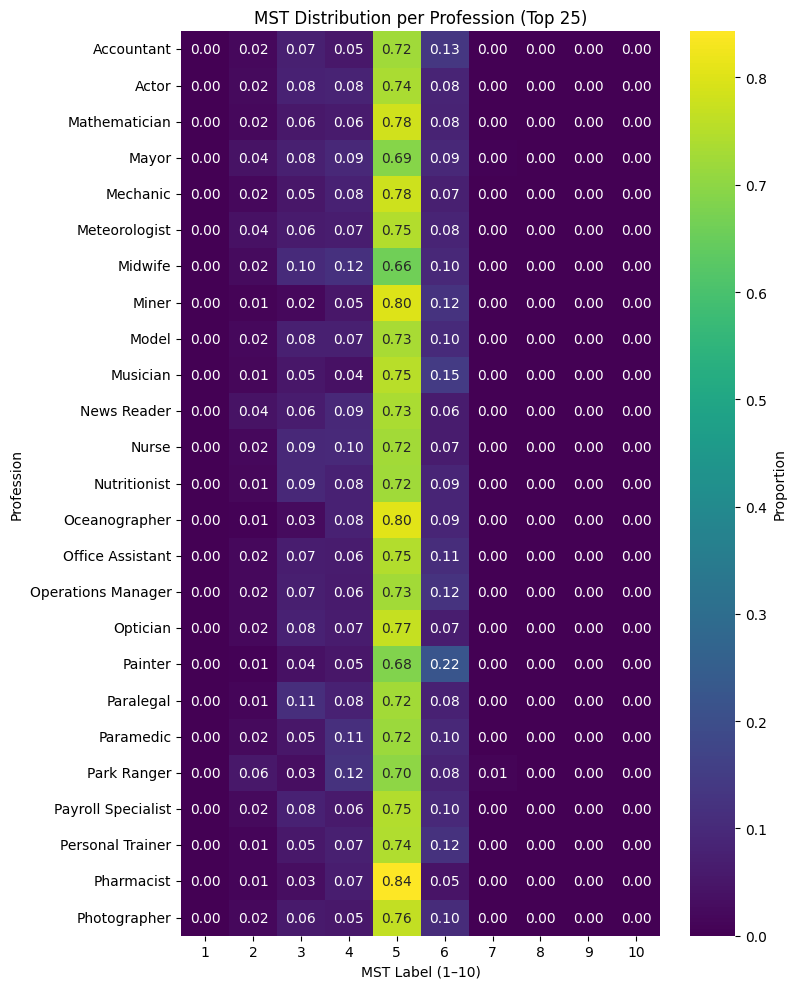

In [ ]:
jsonl_path = r"StableDiffusionGeneratedImages_Annotations\annotations.jsonl"
top_k = 25
label = 'mst_label'
label_list = list(range(1, 11))  # MST labels from 1 to 10
visualise_profession_attribute_distribution(jsonl_path, top_k, label, label_list)

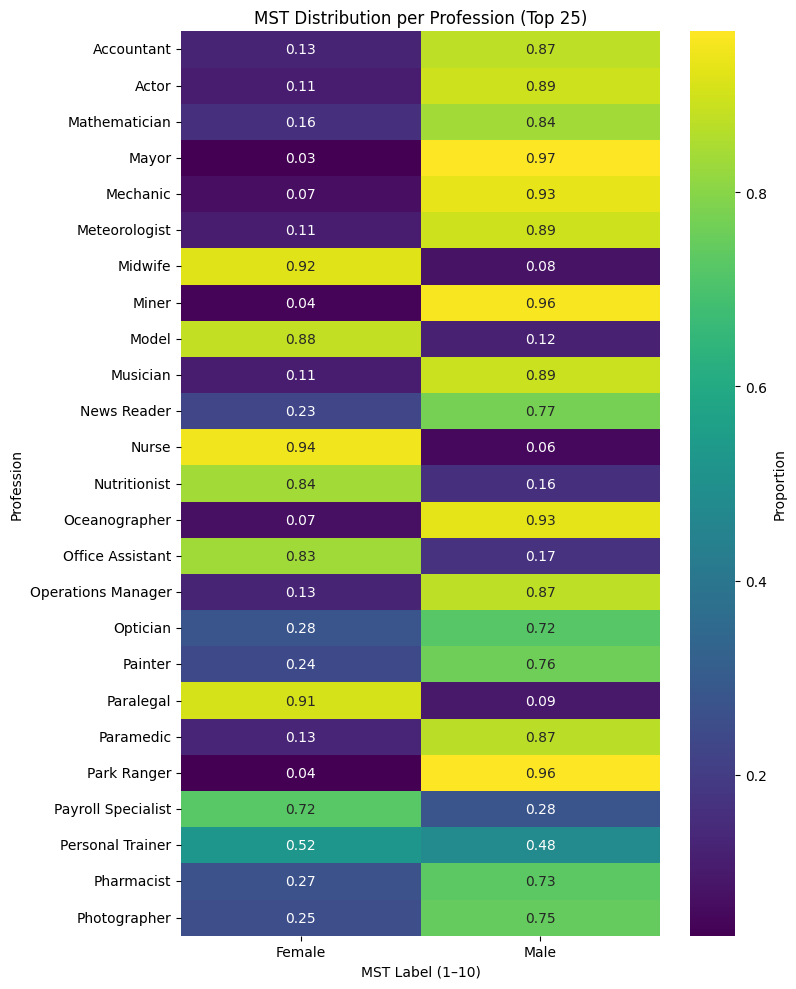

In [ ]:
jsonl_path = r"StableDiffusionGeneratedImages_Annotations\annotations.jsonl"
top_k = 25
label = 'gender'
visualise_profession_attribute_distribution(jsonl_path, top_k, label)

## ReLaion-5B

In [ ]:
# This includes all retrieved images from LAION-5B for the Professions_125k_ISCO_Aligned dataset (not jsut the 1k selected)
jsonl_path = r"Professions_125k_ISCO_Aligned_Annotations\annotations.jsonl"
assess_distribution(jsonl_path)


=== OVERALL ===
Gender: {'Male': 10234248, 'Female': 6607120}
MST label: {5: 11937233, 6: 2627195, 4: 708871, 3: 1124536, 7: 41702, 2: 341898, 8: 41285, 9: 13271, 1: 4568, 10: 809}
Bin: {'Mid (4-7)': 15315001, 'Light (1-3)': 1471002, 'Dark (8-10)': 55365}
Gender × Bin: {('Male', 'Mid (4-7)'): 9425871, ('Female', 'Mid (4-7)'): 5889130, ('Male', 'Light (1-3)'): 772955, ('Female', 'Light (1-3)'): 698047, ('Male', 'Dark (8-10)'): 35422, ('Female', 'Dark (8-10)'): 19943}

=== PER PROFESSION ===

[A_photo_of_a_baker]
  Gender: {'Female': 24141, 'Male': 34017}
  MST: {5: 40552, 6: 10297, 4: 2377, 3: 3509, 7: 180, 2: 1006, 8: 154, 9: 67, 1: 11, 10: 5}
  Bin: {'Mid (4-7)': 53406, 'Light (1-3)': 4526, 'Dark (8-10)': 226}
  Gender × Bin: {('Female', 'Mid (4-7)'): 21705, ('Male', 'Mid (4-7)'): 31701, ('Female', 'Light (1-3)'): 2345, ('Male', 'Light (1-3)'): 2181, ('Male', 'Dark (8-10)'): 135, ('Female', 'Dark (8-10)'): 91}

[A_photo_of_a_banker]
  Gender: {'Male': 64837, 'Female': 25629}
  MST: {

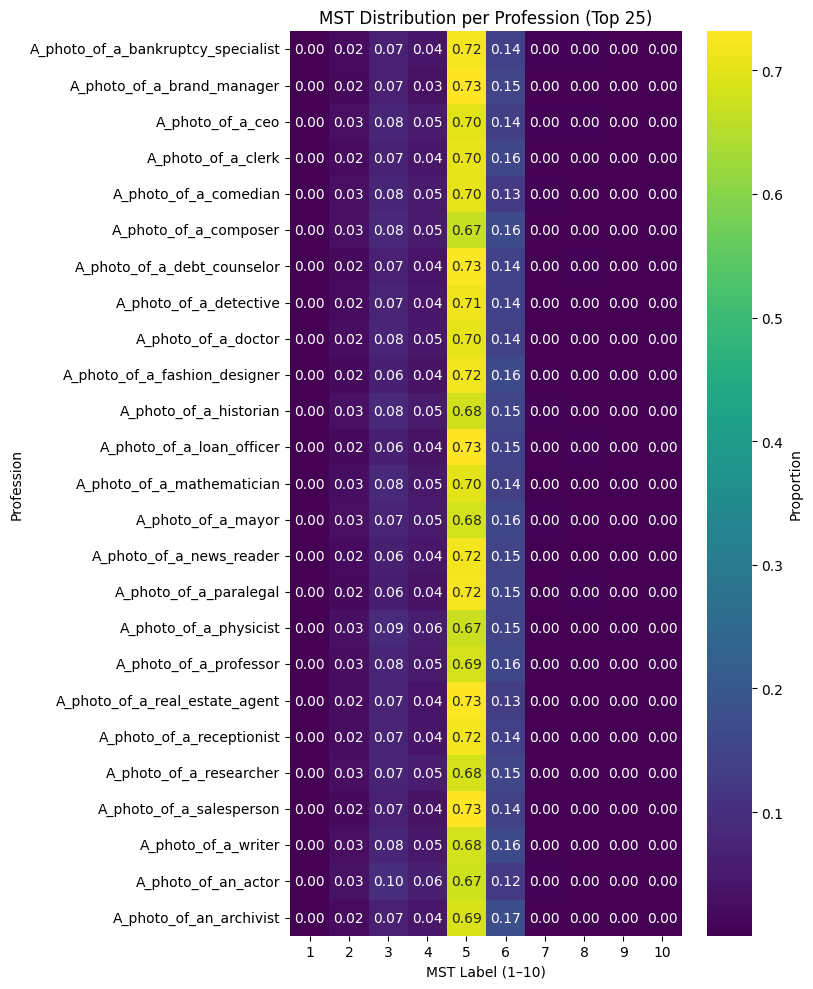

In [ ]:
jsonl_path = r"Professions_125k_ISCO_Aligned_Annotations\annotations.jsonl"
top_k = 25
label = 'mst_label'
label_list = list(range(1, 11))  # MST labels from 1 to 10
visualise_profession_attribute_distribution(jsonl_path, top_k, label, label_list)

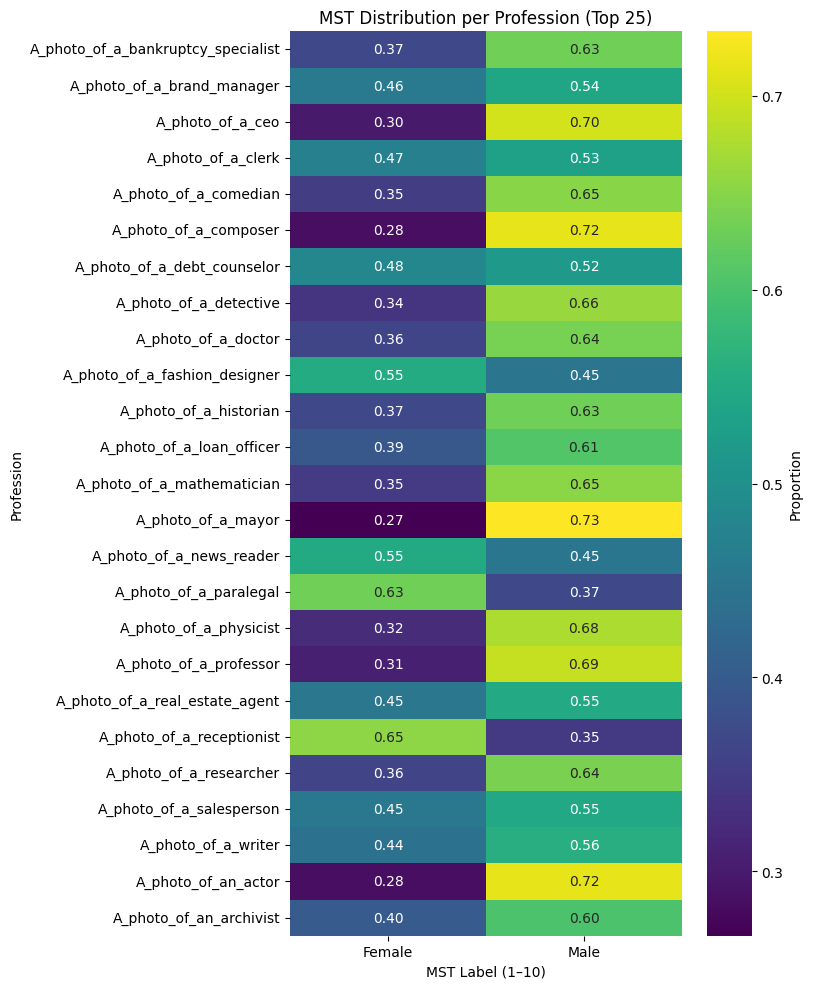

In [ ]:
jsonl_path = r"Professions_125k_ISCO_Aligned_Annotations\annotations.jsonl"
top_k = 25
label = 'gender'
visualise_profession_attribute_distribution(jsonl_path, top_k, label)

## ReLaion-5B 1k Subset

In [ ]:
# This includes all retrieved images from LAION-5B for the Professions_125k_ISCO_Aligned dataset (not jsut the 1k selected)
jsonl_path = r"Professions_125k_ISCO_Aligned_1k_Subset\annotations.jsonl"
assess_distribution(jsonl_path)


=== OVERALL ===
Gender: {'Male': 137372, 'Female': 63628}
MST label: {5: 169791, 3: 1693, 6: 23778, 4: 5084, 2: 343, 7: 238, 8: 72, 9: 1}
Bin: {'Mid (4-7)': 198891, 'Light (1-3)': 2036, 'Dark (8-10)': 73}
Gender × Bin: {('Male', 'Mid (4-7)'): 135999, ('Female', 'Light (1-3)'): 724, ('Female', 'Mid (4-7)'): 62892, ('Male', 'Light (1-3)'): 1312, ('Male', 'Dark (8-10)'): 61, ('Female', 'Dark (8-10)'): 12}

=== PER PROFESSION ===

[A_photo_of_a_baker]
  Gender: {'Male': 721, 'Female': 279}
  MST: {5: 783, 6: 146, 3: 18, 4: 45, 2: 4, 7: 2, 8: 2}
  Bin: {'Mid (4-7)': 976, 'Light (1-3)': 22, 'Dark (8-10)': 2}
  Gender × Bin: {('Male', 'Mid (4-7)'): 702, ('Female', 'Mid (4-7)'): 274, ('Male', 'Light (1-3)'): 18, ('Female', 'Dark (8-10)'): 1, ('Female', 'Light (1-3)'): 4, ('Male', 'Dark (8-10)'): 1}

[A_photo_of_a_banker]
  Gender: {'Male': 831, 'Female': 169}
  MST: {5: 915, 6: 63, 4: 18, 7: 2, 3: 2}
  Bin: {'Mid (4-7)': 998, 'Light (1-3)': 2}
  Gender × Bin: {('Male', 'Mid (4-7)'): 829, ('Fe

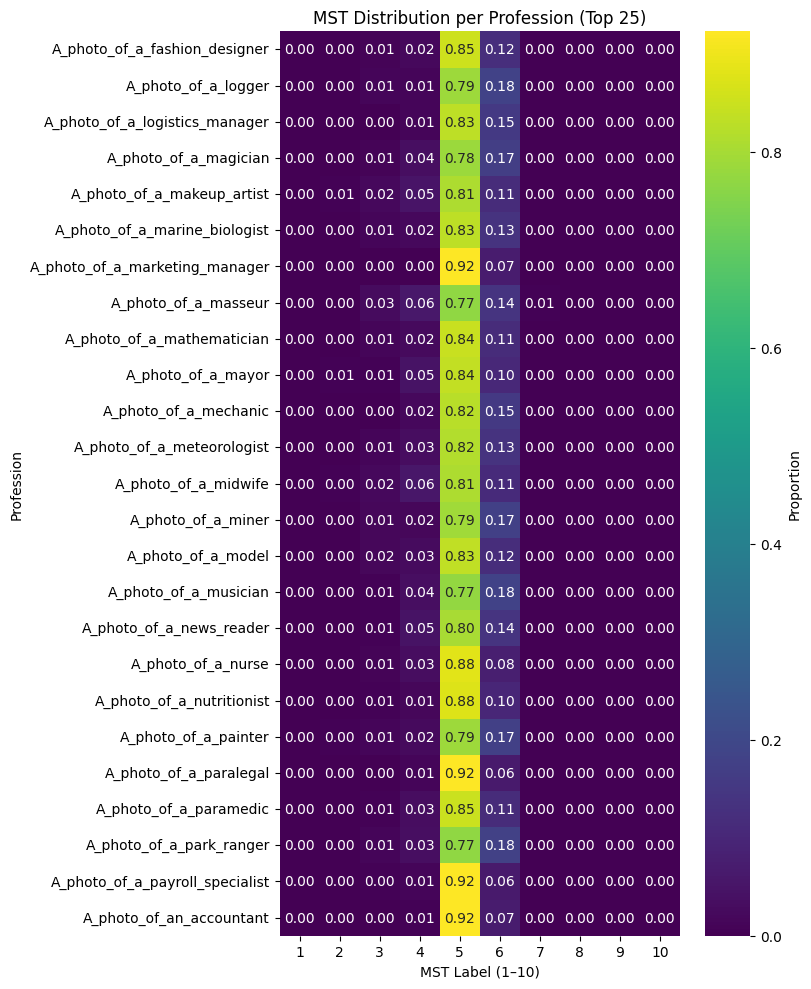

In [ ]:
jsonl_path = r"Professions_125k_ISCO_Aligned_1k_Subset\annotations.jsonl"
top_k = 25
label = 'mst_label'
label_list = list(range(1, 11))  # MST labels from 1 to 10
visualise_profession_attribute_distribution(jsonl_path, top_k, label, label_list)

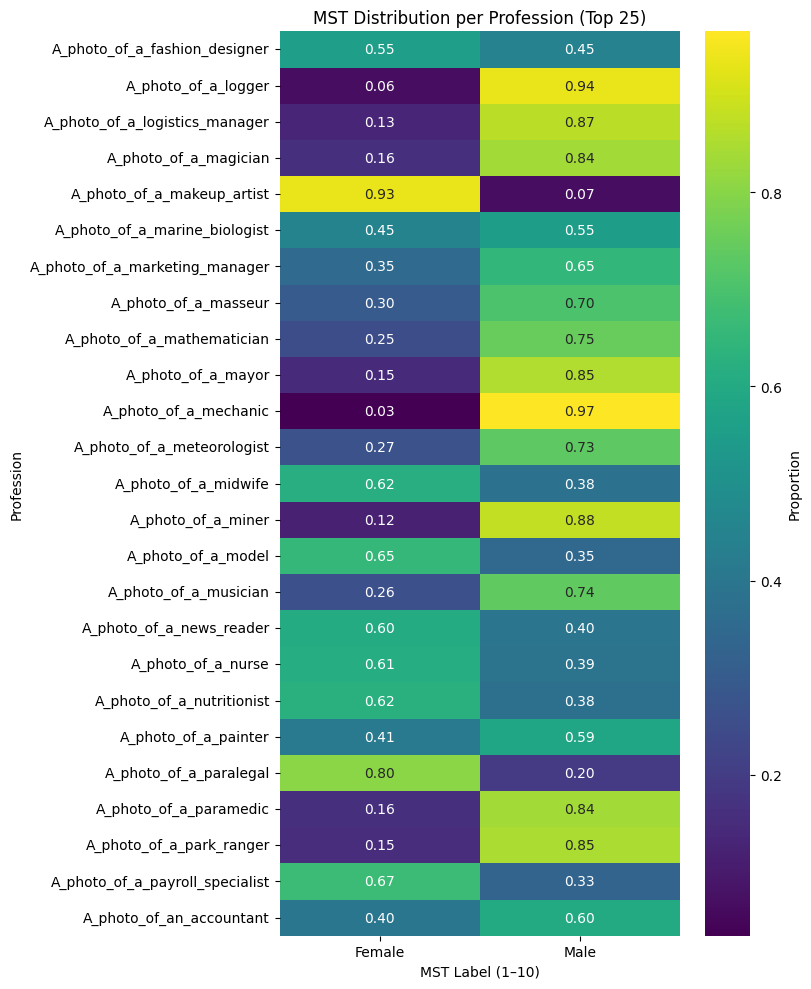

In [ ]:
jsonl_path = r"Professions_125k_ISCO_Aligned_1k_Subset\annotations.jsonl"
top_k = 25
label = 'gender'
visualise_profession_attribute_distribution(jsonl_path, top_k, label)